# Проект: нейросеть для предсказания калорийности блюд

## Этап 1. Исследовательский анализ данных (EDA)

**Цель:** понять, с чем мы работаем, и сформировать стратегию обучения.

**Что исследуем:**
1. Общая статистика по датасету (размер, train/test split)
2. Распределение целевой переменной (`total_calories`)
3. Распределение массы блюда и её связь с калорийностью
4. Ингредиенты: сколько их всего, как часто встречаются, сколько в одном блюде
5. Фотографии: размеры, каналы, примеры
6. Пропуски / некорректные значения

**На выходе:** решения по препроцессингу, аугментациям, архитектуре.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

# === УКАЖИ ПУТЬ К ДАТАСЕТУ ===
DATA_DIR = Path(r'C:\Users\Пользователь1\Downloads\nutrition\data')  # поменяй на свой путь, если датасет лежит в другом месте

assert DATA_DIR.exists(), f'Директория {DATA_DIR} не найдена'
print('Содержимое DATA_DIR:', os.listdir(DATA_DIR))

Содержимое DATA_DIR: ['dish.csv', 'images', 'ingredients.csv']


## 1. Загрузка таблиц

In [2]:
dish = pd.read_csv(DATA_DIR / 'dish.csv')
ingredients = pd.read_csv(DATA_DIR / 'ingredients.csv')

print('dish.csv:', dish.shape)
print('ingredients.csv:', ingredients.shape)
dish.head()

dish.csv: (3262, 5)
ingredients.csv: (555, 2)


,dish_id,total_calories,total_mass,ingredients,split
0,dish_1561662216,300.794281,193.0,ingr_0000000508;ingr_0000000122;ingr_000000002...,test
1,dish_1561662054,419.438782,292.0,ingr_0000000312;ingr_0000000026;ingr_000000002...,train
2,dish_1562008979,382.936646,290.0,ingr_0000000448;ingr_0000000520;ingr_000000046...,test
3,dish_1560455030,20.590000,103.0,ingr_0000000471;ingr_0000000031;ingr_0000000347,train
4,dish_1558372433,74.360001,143.0,ingr_0000000453,train


In [3]:
ingredients.head()

,id,ingr
0,1,cottage cheese
1,2,strawberries
2,3,garden salad
3,4,bacon
4,5,potatoes


In [4]:
# Типы данных и пропуски
print('=== dish.csv ===')
print(dish.dtypes)
print('\nПропуски:')
print(dish.isna().sum())
print('\n=== ingredients.csv ===')
print(ingredients.dtypes)
print('\nПропуски:')
print(ingredients.isna().sum())

=== dish.csv ===
dish_id            object
total_calories    float64
total_mass        float64
ingredients        object
split              object
dtype: object

Пропуски:
dish_id           0
total_calories    0
total_mass        0
ingredients       0
split             0
dtype: int64

=== ingredients.csv ===
id       int64
ingr    object
dtype: object

Пропуски:
id      0
ingr    0
dtype: int64


In [5]:
# Размер train/test
print('Распределение split:')
print(dish['split'].value_counts())
print(f"\nВсего блюд: {len(dish)}")
print(f"Уникальных ингредиентов: {len(ingredients)}")

Распределение split:
split
train    2755
test      507
Name: count, dtype: int64

Всего блюд: 3262
Уникальных ингредиентов: 555


## 2. Целевая переменная — `total_calories`

count    3262.000000
mean      255.012738
std       219.637570
min         0.000000
25%        80.114996
50%       209.110062
75%       375.122963
max      3943.325195
Name: total_calories, dtype: float64


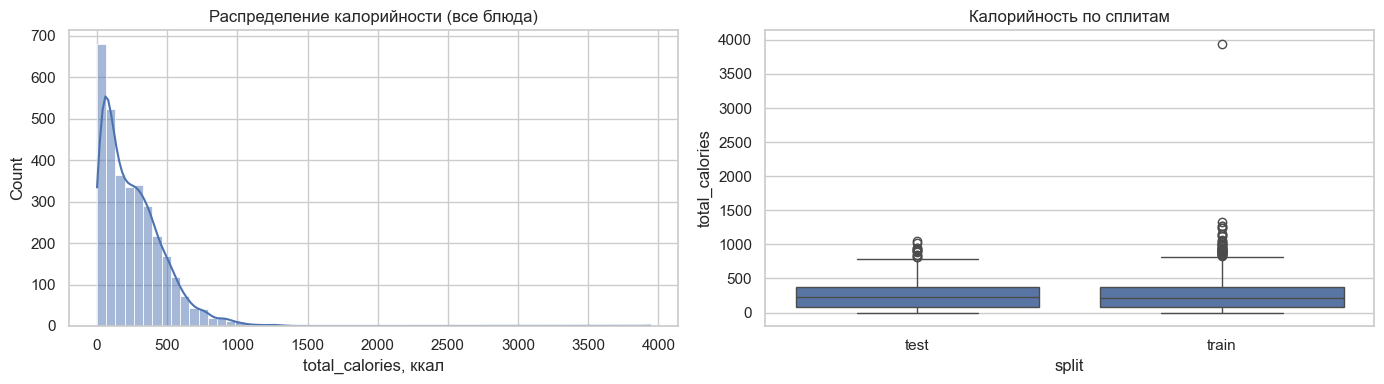

In [6]:
print(dish['total_calories'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(dish['total_calories'], bins=60, kde=True, ax=axes[0])
axes[0].set_title('Распределение калорийности (все блюда)')
axes[0].set_xlabel('total_calories, ккал')

sns.boxplot(data=dish, x='split', y='total_calories', ax=axes[1])
axes[1].set_title('Калорийность по сплитам')
plt.tight_layout(); plt.show()

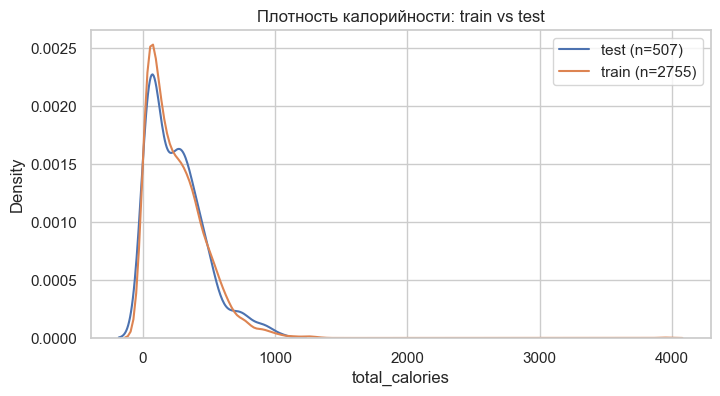


Статистики по сплитам:
        count        mean         std  min        25%         50%         75%  \
split                                                                           
test    507.0  255.467051  212.241674  0.0  74.360001  226.014999  369.684906   
train  2755.0  254.929131  221.009051  0.0  81.805329  208.115997  376.573365   

               max  
split               
test   1050.511108  
train  3943.325195  


In [7]:
# Сравним распределения train vs test — важно чтобы не было сильного сдвига
fig, ax = plt.subplots(figsize=(8, 4))
for split_name in dish['split'].unique():
    subset = dish[dish['split'] == split_name]['total_calories']
    sns.kdeplot(subset, label=f'{split_name} (n={len(subset)})', ax=ax)
ax.set_title('Плотность калорийности: train vs test')
ax.set_xlabel('total_calories')
ax.legend(); plt.show()

print('\nСтатистики по сплитам:')
print(dish.groupby('split')['total_calories'].describe())

## 3. Масса блюда и её связь с калорийностью

Масса — прямой предиктор калорийности. Проверим корреляцию.

count    3262.000000
mean      214.980074
std       161.497428
min         1.000000
25%        92.000000
50%       177.000000
75%       305.000000
max      3051.000000
Name: total_mass, dtype: float64


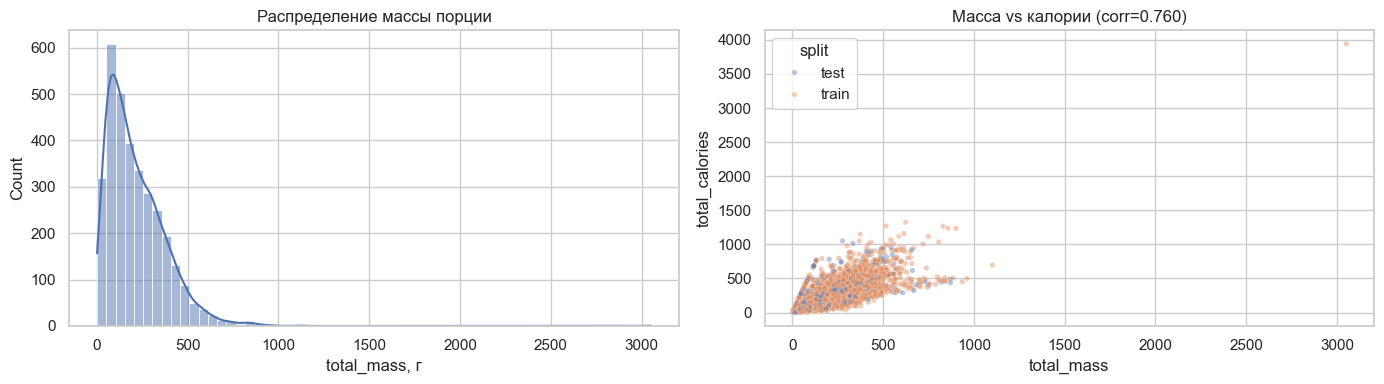

In [8]:
print(dish['total_mass'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(dish['total_mass'], bins=60, kde=True, ax=axes[0])
axes[0].set_title('Распределение массы порции')
axes[0].set_xlabel('total_mass, г')

sns.scatterplot(data=dish, x='total_mass', y='total_calories', 
                hue='split', alpha=0.4, s=15, ax=axes[1])
axes[1].set_title(f"Масса vs калории (corr={dish[['total_mass','total_calories']].corr().iloc[0,1]:.3f})")
plt.tight_layout(); plt.show()

In [9]:
# Baseline: простейшая модель — средняя плотность ккал/г
train_df = dish[dish['split'] == 'train']
test_df  = dish[dish['split'] == 'test']

# Средняя калорийность на грамм (по трейну)
avg_kcal_per_g = (train_df['total_calories'] / train_df['total_mass']).mean()
print(f'Средняя плотность ккал/г по train: {avg_kcal_per_g:.3f}')

# Предсказание baseline = mass * avg_kcal_per_g
baseline_pred = test_df['total_mass'] * avg_kcal_per_g
baseline_mae = (baseline_pred - test_df['total_calories']).abs().mean()
print(f'Baseline MAE (только масса × средняя плотность): {baseline_mae:.2f}')

# Ещё проще: предсказываем среднюю калорийность для всех
mean_cal = train_df['total_calories'].mean()
naive_mae = (test_df['total_calories'] - mean_cal).abs().mean()
print(f'Naive MAE (предсказание = средняя калорийность): {naive_mae:.2f}')

Средняя плотность ккал/г по train: 1.280
Baseline MAE (только масса × средняя плотность): 104.12
Naive MAE (предсказание = средняя калорийность): 168.52


**Вывод:** эти два бейзлайна — наша точка отсчёта. Нейросеть должна обойти хотя бы baseline_mae (масса × средняя плотность).

## 4. Ингредиенты

In [10]:
# Парсим список ID ингредиентов в каждом блюде
def parse_ingredients(s):
    if pd.isna(s) or s == '':
        return []
    # формат: ingr_0000000122;ingr_0000000026;...
    # ненулевая часть — это ID
    tokens = [t.strip() for t in str(s).split(';') if t.strip()]
    ids = []
    for t in tokens:
        # берём числовую часть после 'ingr_'
        if '_' in t:
            num = t.split('_')[-1].lstrip('0') or '0'
            ids.append(int(num))
        else:
            try:
                ids.append(int(t))
            except ValueError:
                pass
    return ids

dish['ingr_ids'] = dish['ingredients'].apply(parse_ingredients)
dish['n_ingredients'] = dish['ingr_ids'].apply(len)

print('Статистика по количеству ингредиентов в блюде:')
print(dish['n_ingredients'].describe())

Статистика по количеству ингредиентов в блюде:
count    3262.000000
mean        7.313305
std         6.943276
min         1.000000
25%         1.000000
50%         4.000000
75%        12.000000
max        34.000000
Name: n_ingredients, dtype: float64


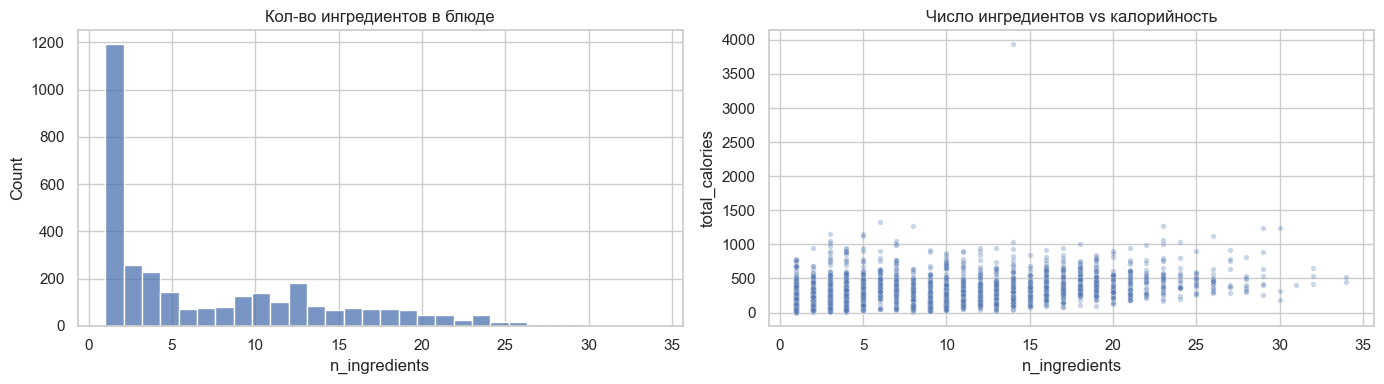

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(dish['n_ingredients'], bins=30, ax=axes[0])
axes[0].set_title('Кол-во ингредиентов в блюде')

sns.scatterplot(data=dish, x='n_ingredients', y='total_calories', alpha=0.3, s=15, ax=axes[1])
axes[1].set_title('Число ингредиентов vs калорийность')
plt.tight_layout(); plt.show()

In [12]:
# Топ-20 самых частых ингредиентов
from collections import Counter

all_ids = [i for ids in dish['ingr_ids'] for i in ids]
counter = Counter(all_ids)
print(f'Уникальных ингредиентов, встречающихся в блюдах: {len(counter)}')
print(f'Всего в справочнике ingredients.csv: {len(ingredients)}')

# Мапим id -> название
id_to_name = dict(zip(ingredients['id'].astype(int), ingredients['ingr']))

top20 = counter.most_common(20)
top20_df = pd.DataFrame(top20, columns=['id', 'count'])
top20_df['name'] = top20_df['id'].map(id_to_name)
top20_df

Уникальных ингредиентов, встречающихся в блюдах: 200
Всего в справочнике ingredients.csv: 555


,id,count,name
0,161,1561,olive oil
1,291,1379,salt
2,122,947,garlic
3,312,723,pepper
4,189,713,vinegar
5,94,686,onions
6,520,572,lemon juice
7,515,506,arugula
8,524,493,parsley
9,471,481,cherry tomatoes


## 5. Фотографии

In [13]:
IMAGES_DIR = DATA_DIR / 'images'

# Проверим что для каждого dish_id есть папка с rgb.png
sample_ids = dish['dish_id'].sample(min(200, len(dish)), random_state=42).tolist()
missing = []
sizes = []
for did in tqdm(sample_ids, desc='Проверка фото'):
    p = IMAGES_DIR / str(did) / 'rgb.png'
    if not p.exists():
        missing.append(did)
    else:
        with Image.open(p) as img:
            sizes.append(img.size + (img.mode,))

print(f'Отсутствующих файлов в выборке 200: {len(missing)}')
if sizes:
    sizes_df = pd.DataFrame(sizes, columns=['width', 'height', 'mode'])
    print('\nРазмеры (на выборке 200):')
    print(sizes_df[['width','height']].describe())
    print('\nМоды каналов:', sizes_df['mode'].value_counts().to_dict())

Проверка фото:   0%|          | 0/200 [00:00<?, ?it/s]

Отсутствующих файлов в выборке 200: 0

Размеры (на выборке 200):
       width  height
count  200.0   200.0
mean   640.0   480.0
std      0.0     0.0
min    640.0   480.0
25%    640.0   480.0
50%    640.0   480.0
75%    640.0   480.0
max    640.0   480.0

Моды каналов: {'RGB': 200}


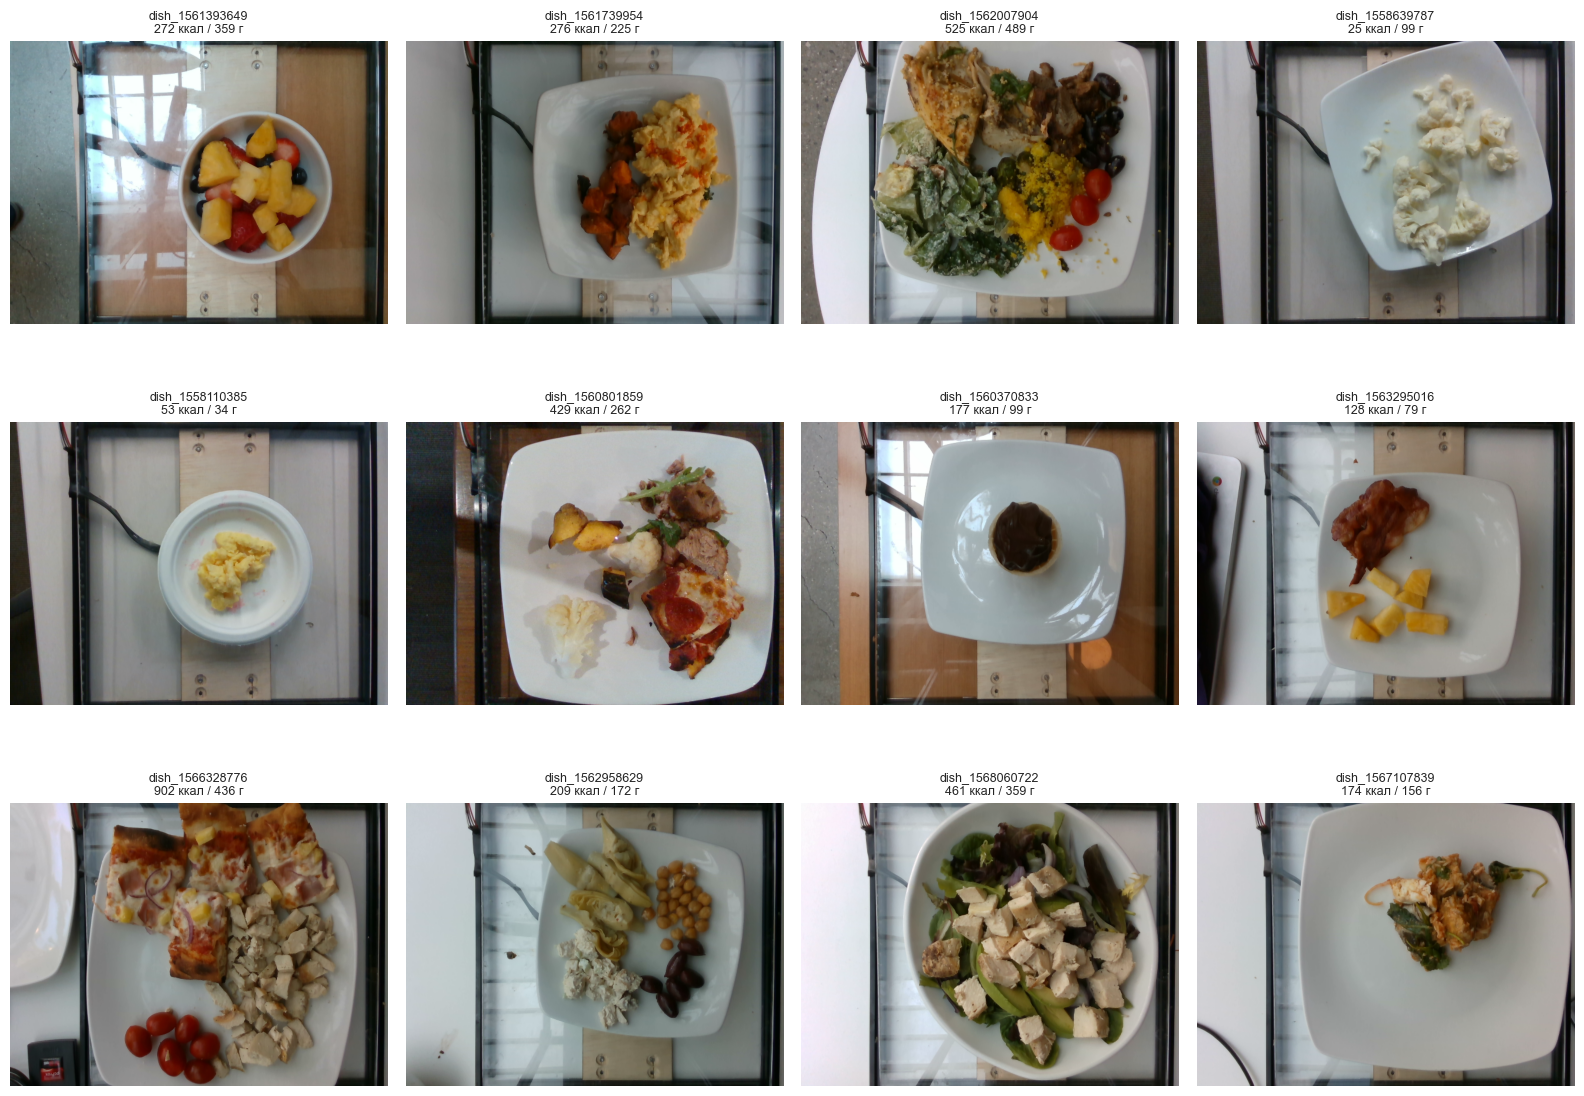

In [14]:
# Посмотрим несколько случайных примеров
sample = dish.sample(12, random_state=42).reset_index(drop=True)
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for i, row in sample.iterrows():
    ax = axes[i // 4, i % 4]
    p = IMAGES_DIR / str(row['dish_id']) / 'rgb.png'
    try:
        img = Image.open(p)
        ax.imshow(img)
    except FileNotFoundError:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center')
    ax.set_title(f"{row['dish_id']}\n{row['total_calories']:.0f} ккал / {row['total_mass']:.0f} г", fontsize=9)
    ax.axis('off')
plt.tight_layout(); plt.show()

## 6. Посмотрим на выбросы

In [15]:
# Самые калорийные и самые лёгкие
print('Топ-5 самых калорийных:')
print(dish.nlargest(5, 'total_calories')[['dish_id','total_calories','total_mass','n_ingredients']])
print('\nТоп-5 с самой низкой калорийностью:')
print(dish.nsmallest(5, 'total_calories')[['dish_id','total_calories','total_mass','n_ingredients']])

# Странные случаи: нулевая масса или нулевые калории
print('\nБлюд с total_mass=0:', (dish['total_mass'] == 0).sum())
print('Блюд с total_calories=0:', (dish['total_calories'] == 0).sum())
print('Блюд без ингредиентов:', (dish['n_ingredients'] == 0).sum())

Топ-5 самых калорийных:
              dish_id  total_calories  total_mass  n_ingredients
1518  dish_1560974769     3943.325195      3051.0             14
124   dish_1565033265     1324.084961       625.0              6
2753  dish_1562603895     1268.157349       517.0              8
1125  dish_1564170010     1264.548340       831.0             23
1951  dish_1563476577     1238.033691       857.0             30

Топ-5 с самой низкой калорийностью:
              dish_id  total_calories  total_mass  n_ingredients
263   dish_1557861216            0.00         1.0              1
2652  dish_1556575700            0.00        86.0              1
195   dish_1558461431            1.15         5.0              1
2018  dish_1558460205            1.84         8.0              1
2222  dish_1558459602            2.07         9.0              1

Блюд с total_mass=0: 0
Блюд с total_calories=0: 2
Блюд без ингредиентов: 0


## 7. Выводы EDA и план решения

_Заполни на основе того, что увидел выше:_

**Что важно:**
- **Масса сильно коррелирует с калориями** → обязательно используем как отдельный признак.
- **Ингредиенты** → используем как multi-hot или embedding+mean.
- **Фото** → для контекста (плотность калорий зависит от типа еды).
- **Распределение калорий** — если скошенное, можно попробовать `log(target)` или `target/mass` как альтернативную цель.

**Решения:**

| Решение | Обоснование |
|---|---|
| Мультимодальная модель (image + ingredients + mass) | Табличные фичи дают больше сигнала, чем фото в одиночку |
| Backbone: EfficientNet-B0 | Быстрый, на 4070 Ti влезает большой батч, хорошо работает на ImageNet-подобных данных |
| Resize 224×224 | Стандартный размер для ImageNet-бэкбонов |
| Нормализация ImageNet-статистиками | Совместимость с предобученными весами |
| Аугментации train: RandomResizedCrop, HFlip, ColorJitter | Еда на фото часто снята под разным освещением и ракурсом |
| Loss: SmoothL1 | Устойчив к выбросам, на последних эпохах можно перейти на L1 |
| Нормализация массы: z-score по train | Чтобы MLP не страдал от разного масштаба фичей |
| Ингредиенты: nn.Embedding + mean | Компактное представление переменной длины |
| Метрики: MAE (целевая), RMSE, R² (для понимания) | MAE — из ТЗ |

---

## Этап 2. Пайплайн обучения — smoke test

Код пайплайна лежит в `scripts/`. Здесь только импортируем и проверяем, что:
1. DataLoader-ы строятся без ошибок и достают данные.
2. Модель строится и делает forward на одном батче.
3. Тренировочный цикл проходит 1 эпоху без падения.

После успешного smoke-теста — переходим к полному обучению (Этап 3).

In [16]:
# Автоперезагрузка модулей при правках в .py-файлах
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
# Делаем scripts/ импортируемым
PROJECT_ROOT = Path('.').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.config import load_config
from scripts.utils import set_seed, train
from scripts.dataset import build_dataloaders
from scripts.model import build_model
import torch

print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

CUDA available: False


In [17]:
# 1) Загружаем конфиг и проверяем DataLoader-ы
cfg = load_config('configs/config.yaml')
set_seed(cfg.seed, deterministic=cfg.deterministic)

data = build_dataloaders(cfg, seed=cfg.seed)
print(f"train={data['train_size']}  val={data['val_size']}  test={data['test_size']}")
print(f"mass mean={data['mass_mean']:.2f}  std={data['mass_std']:.2f}")

# Достанем один батч и посмотрим на содержимое
batch = next(iter(data['train_loader']))
for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        print(f"  {k}: shape={tuple(v.shape)} dtype={v.dtype}")
    else:
        print(f"  {k}: {type(v).__name__} (len={len(v)})")

train=2341  val=413  test=506
mass mean=218.46  std=165.07


c:\Users\Пользователь1\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  image: shape=(64, 3, 224, 224) dtype=torch.float32
  ingr_ids: shape=(64, 40) dtype=torch.int64
  ingr_mask: shape=(64, 40) dtype=torch.float32
  mass_norm: shape=(64,) dtype=torch.float32
  mass: shape=(64,) dtype=torch.float32
  calories: shape=(64,) dtype=torch.float32
  density: shape=(64,) dtype=torch.float32
  dish_id: list (len=64)


In [18]:
# 2) Проверяем forward модели на этом батче
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = build_model(cfg).to(device)
model.eval()

with torch.inference_mode():
    raw = model(
        batch['image'].to(device),
        batch['ingr_ids'].to(device),
        batch['ingr_mask'].to(device),
        batch['mass_norm'].to(device),
    )
print('raw output shape:', raw.shape)
print('sample raw values (density):', raw[:5].cpu().tolist())
print('sample mass:', batch['mass'][:5].tolist())
print('sample target calories:', batch['calories'][:5].tolist())

# Освобождаем память для следующего шага
del model, raw
if torch.cuda.is_available():
    torch.cuda.empty_cache()

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

c:\Users\Пользователь1\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Пользователь1\.cache\huggingface\hub\models--timm--efficientnet_b0.ra_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


raw output shape: torch.Size([64])
sample raw values (density): [0.043075740337371826, 0.056004416197538376, 0.035227615386247635, 0.0787980780005455, 0.08191950619220734]
sample mass: [164.0, 151.0, 639.0, 354.0, 298.0]
sample target calories: [340.9585266113281, 104.3735580444336, 408.25, 542.496337890625, 194.01583862304688]


In [20]:
# 3) Smoke-test: запускаем train() на 2 эпохи. Замеряем время.
# Если всё ок — переходим к Этапу 3 с полными настройками.
import copy, time
smoke_cfg = copy.deepcopy(cfg)
smoke_cfg.train.epochs = 2
smoke_cfg.train.early_stopping_patience = 999  # не хотим раннюю остановку на тесте
smoke_cfg.paths.best_model_name = 'smoke_best.pth'
smoke_cfg.paths.last_model_name = 'smoke_last.pth'

t0 = time.time()
result = train(smoke_cfg)
print(f"\nSMOKE TEST DONE in {(time.time()-t0)/60:.1f} min")
print(f"Best val MAE: {result['best_val_mae']:.2f}")
print(f"\nЕсли цифра уже близка к baseline (~104) — пайплайн работает корректно.")
print(f"Время одной эпохи ≈ {(time.time()-t0)/2/60:.2f} мин — ориентир для Этапа 3.")

[train] device = cpu
[train] preparing dataloaders...
[train] sizes  train=2341  val=413  test=506
[train] mass stats  mean=218.46  std=165.07
[train] building model: efficientnet_b0
[train] params = 4.42M

=== Epoch 1/2 ===


c:\Users\Пользователь1\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[train e1] batch 20/36  loss=0.2536  MAE=123.23
[epoch 1]  train: loss=0.3195 MAE=109.97  |  val: loss=0.1812 MAE=86.16 RMSE=125.53  |  time train=120.9s val=7.1s
[epoch 1] >>> new best val MAE = 86.16, saved to checkpoints\smoke_best.pth

=== Epoch 2/2 ===
[train e2] batch 20/36  loss=0.1759  MAE=83.00
[epoch 2]  train: loss=0.1681 MAE=82.37  |  val: loss=0.1392 MAE=78.27 RMSE=118.56  |  time train=89.1s val=4.2s
[epoch 2] >>> new best val MAE = 78.27, saved to checkpoints\smoke_best.pth

[train] DONE. Best val MAE = 78.27. Best ckpt: checkpoints\smoke_best.pth

SMOKE TEST DONE in 3.7 min
Best val MAE: 78.27

Если цифра уже близка к baseline (~104) — пайплайн работает корректно.
Время одной эпохи ≈ 1.86 мин — ориентир для Этапа 3.


In [21]:
print("torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version (built):", torch.version.cuda)

torch version: 2.7.1+cpu
CUDA available: False
CUDA version (built): None
